# Packages

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import scipy.stats as stats

# Functions and constants

In [2]:
#Calcuates the coefficient of R² from a linear polyfit. Use this to measure how well the climate indices explain rainfall variability. 
def get_r2(x,y):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    return 1-np.sum(residuals**2)/np.sum((y-np.mean(y))**2)
    
#Gives the empirical CDF to plot the distributions. 
def get_percentiles(x):
    y_percentiles = np.arange(101)
    x_percentiles = np.percentile(x,y_percentiles)
    return x_percentiles,y_percentiles
    
#Both get_realpdf and get_normalpdf give the PDf of regression residuals fitted to normal distribution so you can compare. 
def get_realpdf(x,y,nbins):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    bins = np.linspace(-np.max(np.abs(residuals)),np.max(np.abs(residuals)),nbins)
    binmids = bins[1:] - np.diff(bins)/2
    bindensity,_ = np.histogram(residuals,bins=bins,density=True)
    return bindensity,binmids,bins

def get_normalpdf(x,y,binmids):
    polyfit = np.polyfit(x,y,1)
    y_predicted = np.polyval(polyfit,x)
    residuals = y-y_predicted
    mean = np.mean(residuals)
    std = np.std(residuals)
    return stats.norm.pdf(binmids,mean,std)

# Read data

In [3]:
#Rainfall data monthly - data from https://www.bom.gov.au/jsp/ncc/cdio/weatherData/av?p_nccObsCode=139&p_display_type=dataFile&p_startYear=&p_c=&p_stn_num=86071
precip = pd.read_csv('/Users/oliviahugh-jones/Desktop/HONOURS/Data Analysis /Figure_data/086071_Data1.csv')
precip['date'] = pd.to_datetime(dict(year=precip['Year'], month=precip['Month'], day=1))
precip = precip.set_index('date')
rainfall = precip['Monthly Precipitation Total (mm)'].copy()

#DMI (dipole mode index) IOD - data from https://psl.noaa.gov/data/timeseries/month/DMI/
dmi_raw = pd.read_csv('/Users/oliviahugh-jones/Desktop/HONOURS/Data Analysis /Figure_data/dmi_had_long.csv')
dmi_raw['date'] = pd.to_datetime(dmi_raw['Date'], format='mixed', dayfirst=False)
dmi_raw = dmi_raw.set_index('date')['DMI_index']
dmi_raw = dmi_raw[dmi_raw > -999]
dmi = dmi_raw.sort_index()

#SOI (Southern oscillation index) (ENSO) - data from https://www.ncei.noaa.gov/access/monitoring/enso/
soi_wide = pd.read_csv('/Users/oliviahugh-jones/Desktop/HONOURS/Data Analysis /Figure_data/soi.csv')
soi_wide = soi_wide[pd.to_numeric(soi_wide['YEAR'], errors='coerce').notna()]
soi_wide = soi_wide.drop_duplicates(subset='YEAR', keep='first')
soi_wide['YEAR'] = soi_wide['YEAR'].astype(int)

month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
month_cols = [c for c in soi_wide.columns if c in month_map]
soi_long = soi_wide.melt(id_vars='YEAR', value_vars=month_cols, var_name='MONTH', value_name='SOI')
soi_long['month_num'] = soi_long['MONTH'].map(month_map)
soi_long['date'] = pd.to_datetime(dict(year=soi_long['YEAR'], month=soi_long['month_num'], day=1))
soi_long = soi_long.set_index('date').sort_index()
soi = pd.to_numeric(soi_long['SOI'], errors='coerce')
soi = soi.replace(-999.9, np.nan)

# Analysis

In [4]:
#Trims data to all start from same date
start, end = '1951-01-01', '2023-12-01'
rain = rainfall.loc[start:end]
dmi_ts = dmi.loc[start:end]
soi_ts = soi.loc[start:end]

#Merge data 
df = pd.DataFrame({'rainfall': rain, 'SOI': soi_ts, 'DMI': dmi_ts})
df = df.dropna()

In [5]:
annual = rainfall.resample('YE').sum()

#This calculates the 12 month Standardised Precipitation Index (SPI-12)
#Values below -1 indicate moderate to severe drought
rain_roll12 = rainfall.rolling(12, center=True).mean()
rain_mean = rainfall.mean()
rain_std = rainfall.std()
spi12 = (rain_roll12 - rain_mean) / rain_std

# Figure 1: Scatter plots with linear regression: SOI and DMI vs monthly rainfall

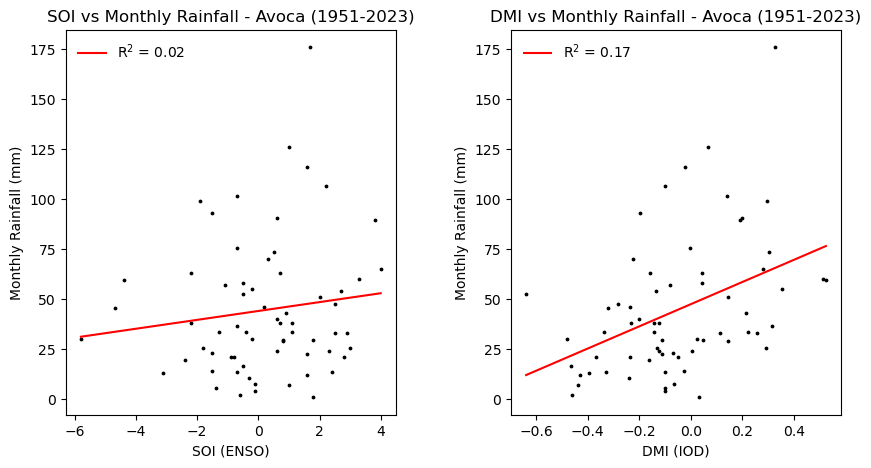

In [27]:
ss = 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.35)

ax1.scatter(df['SOI'], df['rainfall'], c='k', s=ss)
soi_polyfit = np.polyfit(df['SOI'], df['rainfall'], 1)
tempx_soi = np.linspace(df['SOI'].min(), df['SOI'].max(), 100)
ax1.plot(tempx_soi, np.polyval(soi_polyfit, tempx_soi), 'r',
         label='R$^2$ = %.2f' % get_r2(df['SOI'], df['rainfall']))
ax1.set_xlabel('SOI (ENSO)')
ax1.set_ylabel('Monthly Rainfall (mm)')
ax1.set_title('SOI vs Monthly Rainfall - Avoca (1951-2023)')
ax1.legend(frameon=False)

ax2.scatter(df['DMI'], df['rainfall'], c='k', s=ss)
dmi_polyfit = np.polyfit(df['DMI'], df['rainfall'], 1)
tempx_dmi = np.linspace(df['DMI'].min(), df['DMI'].max(), 100)
ax2.plot(tempx_dmi, np.polyval(dmi_polyfit, tempx_dmi), 'r',
         label='R$^2$ = %.2f' % get_r2(df['DMI'], df['rainfall']))
ax2.set_xlabel('DMI (IOD)')
ax2.set_ylabel('Monthly Rainfall (mm)')
ax2.set_title('DMI vs Monthly Rainfall - Avoca (1951-2023)')
ax2.legend(frameon=False)

plt.savefig('fig1_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Lag correlation - how many months ahead do SOI and DMI predict rainfall?

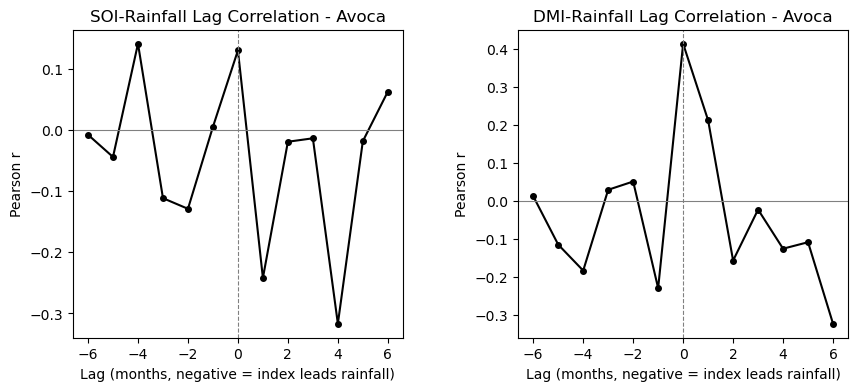

In [26]:
lags = range(-6, 7)
r_soi_lags = []
r_dmi_lags = []

for lag in lags:
    shifted_rain = df['rainfall'].shift(-lag)
    valid = pd.concat([df['SOI'], df['DMI'], shifted_rain], axis=1).dropna()
    valid.columns = ['SOI', 'DMI', 'rainfall']
    r_s, p_s = stats.pearsonr(valid['SOI'], valid['rainfall'])
    r_d, p_d = stats.pearsonr(valid['DMI'], valid['rainfall'])
    r_soi_lags.append(r_s)
    r_dmi_lags.append(r_d)

lags_list = list(lags)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.35)

ax1.plot(lags_list, r_soi_lags, 'k-o', ms=4)
ax1.axhline(0, color='grey', lw=0.8)
ax1.axvline(0, color='grey', lw=0.8, linestyle='--')
ax1.set_xlabel('Lag (months, negative = index leads rainfall)')
ax1.set_ylabel('Pearson r')
ax1.set_title('SOI-Rainfall Lag Correlation - Avoca')

ax2.plot(lags_list, r_dmi_lags, 'k-o', ms=4)
ax2.axhline(0, color='grey', lw=0.8)
ax2.axvline(0, color='grey', lw=0.8, linestyle='--')
ax2.set_xlabel('Lag (months, negative = index leads rainfall)')
ax2.set_ylabel('Pearson r')
ax2.set_title('DMI-Rainfall Lag Correlation - Avoca')

plt.savefig('fig2_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Percentile plots of rainfall, SOI and DMI

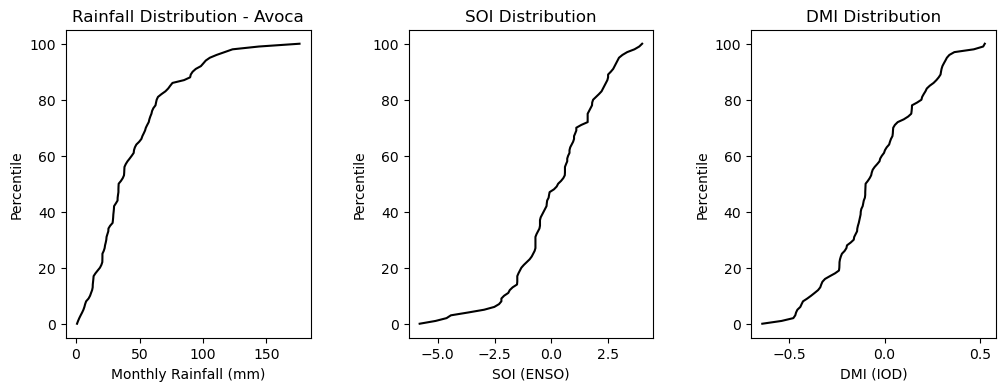

In [25]:
rain_pc, y_pc = get_percentiles(df['rainfall'].values)
soi_pc, _ = get_percentiles(df['SOI'].values)
dmi_pc, _ = get_percentiles(df['DMI'].values)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
fig.subplots_adjust(wspace=0.4)

ax1.plot(rain_pc, y_pc, 'k')
ax1.set_xlabel('Monthly Rainfall (mm)')
ax1.set_ylabel('Percentile')
ax1.set_title('Rainfall Distribution - Avoca')

ax2.plot(soi_pc, y_pc, 'k')
ax2.set_xlabel('SOI (ENSO)')
ax2.set_ylabel('Percentile')
ax2.set_title('SOI Distribution')

ax3.plot(dmi_pc, y_pc, 'k')
ax3.set_xlabel('DMI (IOD)')
ax3.set_ylabel('Percentile')
ax3.set_title('DMI Distribution')

plt.savefig('fig3_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4: PDF of regression residuals vs normal distribution

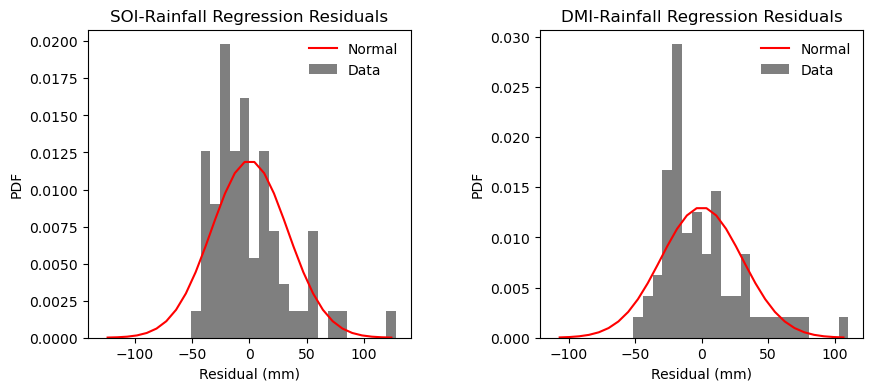

In [23]:
nbins = 31

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.4)

bindensity_soi, binmids_soi, bins_soi = get_realpdf(df['SOI'], df['rainfall'], nbins)
normalpdf_soi = get_normalpdf(df['SOI'], df['rainfall'], binmids_soi)
ax1.bar(binmids_soi, bindensity_soi, width=np.diff(bins_soi)[0], color='k', alpha=0.5, label='Data')
ax1.plot(binmids_soi, normalpdf_soi, 'r', label='Normal')
ax1.set_xlabel('Residual (mm)')
ax1.set_ylabel('PDF')
ax1.set_title('SOI-Rainfall Regression Residuals')
ax1.legend(frameon=False)

bindensity_dmi, binmids_dmi, bins_dmi = get_realpdf(df['DMI'], df['rainfall'], nbins)
normalpdf_dmi = get_normalpdf(df['DMI'], df['rainfall'], binmids_dmi)
ax2.bar(binmids_dmi, bindensity_dmi, width=np.diff(bins_dmi)[0], color='k', alpha=0.5, label='Data')
ax2.plot(binmids_dmi, normalpdf_dmi, 'r', label='Normal')
ax2.set_xlabel('Residual (mm)')
ax2.set_ylabel('PDF')
ax2.set_title('DMI-Rainfall Regression Residuals')
ax2.legend(frameon=False)

plt.savefig('fig4_residual_pdf.png', dpi=150, bbox_inches='tight')
plt.show()